# Denoising network — iter3 : Unsupervised / Label-free

iter2(supervised, test PSNR 34.337 / SSIM 0.9427) 를 기준선으로, **clean label 을 쓰지 않는 학습**을 검증한다.

## 1. 학습 방식 (`config.train_mode`)

| mode | 입력 | target | clean 사용 | 설명 |
|---|---|---|---|---|
| **`n2n`** (기본) | noisy A | **noisy B** | **없음** | Noise2Noise. 같은 clean 의 독립적인 두 노이즈 실현 |
| **`n2v`** | blind-spot 마스킹된 noisy | **같은 noisy 의 마스킹 위치 값** | **없음** | Noise2Void. 단일 noisy 만 사용 |
| `supervised12` | noisy | clean | 사용 | 규칙 준수 대조군 (clean 당 12장 상한) |
| `supervised` | noisy | clean | 사용 | iter2 방식 (매 epoch 새 노이즈) |

> `n2n` / `n2v` 는 **손실 함수에 clean 을 한 번도 넣지 않는다.** clean 은 validation PSNR/SSIM 계산에만 쓰인다.

## 2. 규칙 준수: clean 1장당 corrupted 12장 고정

챌린지 규칙 (`Day 1.md:257-260`):

```
- For each clean image, you may generate up to 6 dipole kernel orientations.
- For each orientation, you may generate up to 2 noisy images.
- Do not exceed 12 corrupted images per clean image (6 orientations × 2 noises)
```

**iter2 는 on-the-fly 노이즈를 60 epoch 반복해 clean 당 60장을 소비했다 (상한의 5배).**

iter3 은 `(파일명, group, member)` 조합으로 corrupted 를 결정론적으로 확정한다.

- `variant_groups = 6` : orientation 자리 (dipole 미적용이므로 현재는 group 인덱스로만 사용)
- `variant_per_group = 2` : group 당 noisy 2장
- 따라서 **clean 1장당 정확히 6 × 2 = 12장**. epoch 을 몇 번 돌려도 이 풀에서만 샘플링한다.

그리고 이 구조가 그대로 **N2N 의 pair 6쌍**이 된다. 규칙 준수와 label-free 학습이 같은 설계로 해결된다.

| | corrupted / clean | 규칙(12) |
|---|---|---|
| iter1 (10 epoch, on-the-fly) | 10 | 이내 |
| iter2 (60 epoch, on-the-fly) | 60 | **5배 초과** |
| **iter3 (고정 풀)** | **12** | **정확히 충족** |

## 3. 손실 함수: L1 (기본값 변경)

iter2 는 L2 였다. iter3 의 label-free 모드는 **L1 을 기본**으로 한다.

N2N 이론: `argmin E‖f(x_a) − x_b‖²` 는 `E[x_b | x_a]` 로 수렴하고, 노이즈가 zero-mean 이면 이것이 clean 이다.
그런데 이 과제의 4종 중 2종이 zero-mean 이 아니다.

| noise | zero-mean | L2 (조건부 평균) | L1 (조건부 median) |
|---|---|---|---|
| gaussian | O | 정확 | 약간 손실 |
| uniform | O | 정확 | 약간 손실 |
| rician | **X (양의 bias)** | bias 잔존 | 개선 |
| salt_and_pepper | **X (impulse)** | outlier 에 끌려감 | **정확** |

Rician 은 `E[|s + n|] > s` 이고 신호가 0인 영역에서 `E = σ√(π/2) ≈ 1.25σ` 다. σ=0.15 면 [0,1] 이미지에 **0.19 의 계통 오차**가 남는다.
salt & pepper 는 impulse 가 손실을 지배한다. 두 경우 모두 L1(median) 이 옳다.

## 4. 모델 선택: `config.select_by`

| 값 | 기준 | clean 사용 |
|---|---|---|
| `"psnr"` (기본) | validation PSNR | **사용** (약한 지도) |
| `"selfsup"` | validation self-supervised loss | **없음** (완전 label-free) |

`"psnr"` 로 돌려도 self-supervised validation loss 를 매 epoch 함께 기록하므로,
`history.json` 에서 **"clean 을 전혀 안 썼다면 몇 번째 epoch 을 골랐을지"** 를 사후에 확인할 수 있다.
발표에서 "완전 label-free 파이프라인" 을 주장하려면 `select_by="selfsup"` 로 한 번 더 돌리거나 이 기록을 근거로 제시한다.

## 5. 예상 결과와 실패 모드 (발표 소재)

label-free 는 supervised 를 PSNR 로 이기지 못한다. 강의자료도 "**partial** bonus consideration" 이라고만 한다.
중요한 것은 **격차가 왜 생기는지**를 정량적으로 설명하는 것이다.

- **n2n**: gaussian / uniform 은 supervised 에 근접, rician / salt&pepper 는 더 벌어질 것으로 예상
- **n2v**: 전반적으로 n2n 보다 낮다. 이유:
  - blind-spot 은 `E[noisy | 주변]` 을 추정 → Rician 의 양의 bias 가 그대로 남는다
  - 마스킹 픽셀에서만 손실이 걸려 supervised 대비 gradient 신호가 훨씬 희소하다
  - 추론 시에는 마스킹 없이 입력하므로 중심 픽셀 정보가 일부 통과한다 (N2V 의 알려진 한계)
  - **blur 는 제거하지 못한다** (dipole 단계에서 무력)
- iter2 에서 salt & pepper 가 +8.29 dB 로 상전이했다. impulse 검출은 label-free 로도 학습 가능한지가 관전 포인트다.

## 6. 권장 실행 순서

각 run 약 1시간 20분 (60 epoch). 아래 셀에서 `config.train_mode` 만 바꿔 순차 실행하고,
마지막 비교 셀에서 run 들을 모아 표로 만든다.

| 순서 | `train_mode` | `loss_model` | 목적 |
|---|---|---|---|
| A | `"n2n"` | `"l1"` | 주 실험 (label-free) |
| B | `"n2v"` | `"l1"` | 완전 label-free |
| C | `"supervised12"` | `"l2"` | 규칙 준수 supervised. iter2 의 이득 중 얼마가 "무제한 variant" 에서 왔는지 분리 |

---

DnCNN 을 이용하여 noisy semiconductor image 의 denoising network 를 학습한다.
학습이 끝난 뒤 best checkpoint 로 test 데이터셋을 검증하고, conventional method 와 비교한다.


In [1]:
# Colab 에서만 Google Drive 를 mount 한다. 로컬 실행이면 건너뛴다.
try:
    from google.colab import drive

    drive.mount("/content/drive/")
except ImportError:
    print("Google Colab 환경이 아니므로 Drive mount 를 건너뜁니다.")

Mounted at /content/drive/


In [2]:
# loguru 는 Colab 기본 이미지에 없으므로 필요할 때만 설치
try:
    import loguru  # noqa: F401
except ImportError:
    !pip install -q loguru

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.5 MB/s eta 0:00:00


## 1. Config

In [3]:
import glob
import json
import math
import os
import random
import zlib
import time
import warnings
from collections.abc import Callable
from dataclasses import asdict, dataclass, field
from datetime import datetime
from enum import Enum, IntEnum
from pathlib import Path
from typing import Any, Literal

import numpy as np
import torch
from scipy.io import loadmat, savemat
from torch import Tensor, nn
from torch.nn import functional
from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# Colab 이면 Google Drive 경로, 로컬이면 저장소의 ref/ 를 자동으로 찾는다.
ROOT = Path("/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습")
WORK_ROOT = ROOT

if not ROOT.exists():
    _here = Path.cwd().resolve()
    for _cand in (_here, *_here.parents):
        if (_cand / "ref" / "dataset").is_dir():
            ROOT = _cand / "ref"
            WORK_ROOT = _cand / "claude"
            break
    else:
        print(f"dataset 을 찾지 못했다. ROOT 를 직접 지정할 것. (cwd={_here})")

WORK_ROOT.mkdir(parents=True, exist_ok=True)

DATA_ROOT = ROOT / "dataset"
RUN_DIR = WORK_ROOT / "logs_denoising"
CHECKPOINT_DIR = WORK_ROOT / "checkpoint_best.ckpt"

print("ROOT     :", ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("RUN_DIR  :", RUN_DIR)

# 학습/검증에 얹을 노이즈를 4종 중 랜덤으로 고를 때 쓰는 sigma 범위
NOISE_RANGES: dict[str, tuple[float, float]] = {
    "gaussian": (0.0, 0.1),
    "rician": (0.0, 0.15),
    "uniform": (0.0, 0.2),
    "salt_and_pepper": (0.0, 0.2),
}

if not ROOT.exists():
    print(f"Root directory {ROOT} does not exist. Please check the path.")


@dataclass
class GeneralConfig:
    # Dataset
    train_dataset: list[str] = field(default_factory=lambda: [str(DATA_ROOT / "train")])
    valid_dataset: list[str] = field(default_factory=lambda: [str(DATA_ROOT / "val")])
    test_dataset: list[str] = field(default_factory=lambda: [str(DATA_ROOT / "test_label")])
    data_type: str = "*.npy"
    # [iter2-C] test_label 은 전부 L1_ 이므로 validation(=모델 선택)도 L1_ 로 맞춘다.
    #           None 이면 data_type 을 그대로 쓴다.
    valid_data_type: str | None = "L1_*.npy"

    test_noisy_dir: str | None = None

    # Logging
    log_lv: str = "INFO"
    run_dir: Path = RUN_DIR
    init_time: float = 0.0

    # Model experiment
    model_type: Literal["dncnn"] = "dncnn"

    # Optimizer
    optimizer: Literal["adam", "adamw"] = "adam"
    loss_model: Literal["l1", "l2"] = "l1"  # [iter3] label-free 모드는 L1(조건부 median) 이 옳다
    lr: float = 1e-4
    lr_decay: float = 0.88  # lr_schedule == "exp" 일 때만 사용
    lr_tol: int = 1  # 이 epoch 수만큼은 초기 lr 을 유지한다
    # [iter2-B] cosine annealing. iter1 의 exp decay 는 학습이 아직 오르는 중에 LR 을 줄였다.
    lr_schedule: Literal["exp", "cosine"] = "cosine"
    lr_min_ratio: float = 0.02  # cosine 최저 LR = lr * lr_min_ratio

    # Train params
    gpu: str = "0"
    train_batch: int = 16
    valid_batch: int = 1
    train_epoch: int = 60  # [iter2-A] iter1(10) 은 마지막 epoch 까지 val PSNR 이 상승 중이었다
    logging_density: int = 4
    valid_interval: int = 1
    valid_tol: int = 0
    num_workers: int = 2
    save_val: bool = True
    parallel: bool = False  # Colab 은 보통 GPU 1장이므로 DataParallel 비활성
    device: torch.device | None = None
    save_max_idx: int = 500

    # [iter2-D] epoch 을 60 으로 늘린 부작용 차단. best checkpoint 는 주기와 무관하게 항상 저장된다.
    ckpt_interval: int = 10  # per-epoch 체크포인트 저장 주기 (1 이면 매 epoch)
    fig_interval: int = 10  # validation 비교 이미지 저장 주기 (1 이면 매 epoch)

    # 빠른 실험/스모크 테스트용 이미지 수 상한 (None 이면 전체 사용)
    max_train_images: int | None = None
    max_valid_images: int | None = None

    # Experiment
    noise_type: Literal["random"] = "random"
    noise_sigma: float = 0.05  # noise_type 이 "random" 이 아닐 때만 사용

    # ---------------- [iter3] unsupervised / label-free ----------------
    # n2n          : 같은 clean 의 두 noisy 실현으로 학습 (clean 미사용)
    # n2v          : 단일 noisy blind-spot 학습 (clean 미사용)
    # supervised12 : clean target. 단 corrupted 는 clean 당 12장 고정 풀에서만
    # supervised   : iter2 방식 (매 epoch 새 노이즈). 규칙 상한 초과 주의
    train_mode: Literal["n2n", "n2v", "supervised12", "supervised"] = "n2n"

    # 규칙 준수: clean 1장당 corrupted <= variant_groups * variant_per_group
    # 6 x 2 = 12 로 "6 orientations x 2 noises" 상한을 정확히 충족한다.
    variant_groups: int = 6
    variant_per_group: int = 2

    # N2V blind-spot 파라미터
    n2v_mask_ratio: float = 0.05  # 마스킹할 픽셀 비율. 낮추면 gradient 가 희소해 학습이 느리다
    n2v_window: int = 5  # 대체 픽셀을 뽑을 이웃 창 크기 (홀수)

    # 모델 선택 기준. "selfsup" 은 clean 을 전혀 쓰지 않는다 (완전 label-free)
    select_by: Literal["psnr", "selfsup"] = "psnr"

    tag: str = ""


@dataclass
class DnCNNConfig:
    # Model architecture
    channels: int = 1
    num_of_layers: int = 17
    kernel_size: int = 3
    padding: int = 1
    features: int = 64


config = GeneralConfig()
dncnnconfig = DnCNNConfig()

# 배포된 데이터는 test_noise_only/test_noise_only/*.npy 로 한 단계 더 깊다. 자동 보정한다.
_test_noisy = DATA_ROOT / "test_noise_only"
if not any(_test_noisy.glob("*.npy")) and any((_test_noisy / "test_noise_only").glob("*.npy")):
    _test_noisy = _test_noisy / "test_noise_only"
config.test_noisy_dir = str(_test_noisy)
print("test_noisy_dir:", config.test_noisy_dir, "| npy:", len(list(Path(config.test_noisy_dir).glob("*.npy"))))

# Windows + Jupyter 에서 DataLoader worker 가 자주 멈추므로 0 으로 둔다.
if os.name == "nt":
    config.num_workers = 0

# ---------------- [iter3] 학습 방식 요약 출력 ----------------
_budget = config.variant_groups * config.variant_per_group
print()
print(f"train_mode      : {config.train_mode}")
print(f"loss_model      : {config.loss_model}")
print(f"select_by       : {config.select_by}")
if config.train_mode == "supervised":
    print(f"corrupted/clean : {config.train_epoch} (on-the-fly, 규칙 상한 12 초과!)")
else:
    print(f"corrupted/clean : {_budget} (= {config.variant_groups} groups x {config.variant_per_group}) <= 12  규칙 준수")
if config.train_mode == "n2v":
    print(f"n2v mask        : ratio={config.n2v_mask_ratio} window={config.n2v_window}")
print(f"clean label 사용 : {'없음 (label-free)' if config.train_mode in ('n2n', 'n2v') else '사용 (supervised)'}")

for k, v in asdict(config).items():
    print(f"{k}: {v}")

ROOT     : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습
DATA_ROOT: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset
RUN_DIR  : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising
test_noisy_dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_noise_only/test_noise_only | npy: 100

train_mode      : n2n
loss_model      : l1
select_by       : psnr
corrupted/clean : 12 (= 6 groups x 2) <= 12  규칙 준수
clean label 사용 : 없음 (label-free)
train_dataset: ['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/train']
valid_dataset: ['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/val']
test_dataset: ['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_label']
data_type: *.npy
valid_data_type: L1_*.npy
test_noisy_dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_noise_only/test_noise_only
log_lv: INFO
run_dir: /content/drive/MyDrive/DS2026/20

## 2. utils



In [4]:
def timestamp() -> str:
    return datetime.fromtimestamp(time.time()).strftime("%Y%m%d-%H%M%S")


def separator(cols: int = 100) -> str:
    return "#" * cols


def seconds_to_dhms(seconds: float) -> str:
    s = seconds % 60
    m = (seconds // 60) % 60
    h = seconds // (60 * 60) % 1000
    return f"{int(h):02}h {int(m):02}m {int(s):02}s"


def call_next_id(run_dir: Path) -> int:
    run_ids = []
    os.makedirs(run_dir, exist_ok=True)
    for entry in os.listdir(run_dir):
        if (run_dir / entry).is_dir():
            try:
                run_ids.append(int(entry.split("_")[0]))
            except ValueError:
                continue
    return max(run_ids, default=-1) + 1


def validate_tensors(tensors: list[Tensor]) -> None:
    for i, t in enumerate(tensors):
        if not isinstance(t, Tensor):
            raise TypeError(f"Tensor at index {i} is not a torch.Tensor, got {type(t)} instead.")


def validate_tensor_dimensions(tensors: list[Tensor], expected_dim: int) -> None:
    for i, t in enumerate(tensors):
        if t.dim() != expected_dim:
            raise ValueError(f"Tensor at index {i} has {t.dim()} dimensions, expected {expected_dim} dimensions.")


def validate_tensor_channels(tensor: Tensor, expected_channels: int) -> None:
    if tensor.shape[1] != expected_channels:
        raise ValueError(f"Expected tensor with {expected_channels} channels, but got {tensor.shape[1]} channels.")

## 3. logger

In [5]:
import inspect
import sys
import traceback
from functools import wraps

from loguru import logger as logurulogger

LOGURU_LEVEL = ["TRACE", "DEBUG", "INFO", "SUCCESS", "WARNING", "ERROR", "CRITICAL"]
FORMAT = "{time:YYYY-MM-DD HH:mm:ss} <level>[{level}]</level> {message}"
LOGURU_LV_LOWER = [x.lower() for x in LOGURU_LEVEL]


class SingletonMeta(type):
    _instances: dict[Any, Any] = {}

    def __call__(cls, *args, **kwargs):
        if cls not in cls._instances:
            instance = super().__call__(*args, **kwargs)
            cls._instances[cls] = instance
        return cls._instances[cls]


class CustomLogger(metaclass=SingletonMeta):
    def __getattr__(self, name: str) -> Any:
        if name not in LOGURU_LV_LOWER:
            return getattr(logurulogger, name)

        def custom_handler(message: str | Any) -> None:
            if name == "error":
                caller_name = inspect.stack()[1].function
                getattr(logurulogger, name)(f"Error in func {caller_name}")

            if isinstance(message, str):
                processed_message = message.split("\n")
                for _item in processed_message:
                    getattr(logurulogger, name)(_item)
            else:
                getattr(logurulogger, name)(message)

        return custom_handler

    def trace(self, message: Any) -> None:
        self.__getattr__("trace")(message)

    def debug(self, message: Any) -> None:
        self.__getattr__("debug")(message)

    def info(self, message: Any) -> None:
        self.__getattr__("info")(message)

    def success(self, message: Any) -> None:
        self.__getattr__("success")(message)

    def warning(self, message: Any) -> None:
        self.__getattr__("warning")(message)

    def error(self, message: Any) -> None:
        self.__getattr__("error")(message)

    def critical(self, message: Any) -> None:
        self.__getattr__("critical")(message)


def logger_add_handler(
    _logger: CustomLogger,
    file: str | Path | None = None,
    level: str | None = None,
) -> None:
    _logger.remove()
    if level is None:
        level = "TRACE"
    _logger.add(
        sys.stdout,
        colorize=True,
        format=FORMAT,
        level=level,
    )
    if file is None:
        return
    _logger.add(
        file,
        colorize=True,
        format=FORMAT,
        level=level,
    )


logger = CustomLogger()
logger_add_handler(logger)


# common/wrapper.py 의 error_wrap
def error_wrap(func: Callable) -> Callable:
    @wraps(func)
    def sync_wrapper(*args: Any, **kwargs: Any) -> Any:
        try:
            return func(*args, **kwargs)
        except Exception as err:
            logger.error(f"Error in {func.__name__}: {err}\n{traceback.format_exc()}")
            return None

    return sync_wrapper

## 4. MetricController

In [6]:
class MetricController:
    def __init__(self) -> None:
        self.state_dict: dict[str, list[float]] = {}

    def reset(self) -> None:
        self.state_dict = {}

    def add(
        self,
        key: str,
        value: torch.Tensor,
    ) -> None:
        if not isinstance(key, str):
            raise TypeError(f"{key} is not a string")

        if not isinstance(value, torch.Tensor):
            raise TypeError(f"{value} is not torch.Tensor")

        if key not in self.state_dict:
            self.state_dict[key] = []

        if value.dim() == 4 and value.shape[1:] == (1, 1, 1):
            value = value.view(-1)
        elif value.dim() == 1:
            pass
        else:
            raise ValueError(f"Expected value to have shape (b, 1, 1, 1) or (b,), but got {value.shape}")

        value = value.cpu().detach().numpy()
        self.state_dict[key].extend(value.flatten())

    def mean(self, key: str) -> float:
        if key not in self.state_dict or len(self.state_dict[key]) == 0:
            raise ValueError(f"No values found for key: {key}")
        return np.mean(self.state_dict[key])

    def std(self, key: str) -> float:
        if key not in self.state_dict or len(self.state_dict[key]) == 0:
            raise ValueError(f"No values found for key: {key}")
        return np.std(self.state_dict[key], ddof=1)

## 5. PSNR / SSIM

In [7]:
IMG_DIM: int = 4


class SSIMcal(torch.nn.Module):
    def __init__(
        self,
        win_size: int = 11,
        k1: float = 0.01,
        k2: float = 0.03,
    ):
        super().__init__()
        self.win_size = win_size
        self.k1, self.k2 = k1, k2
        self.register_buffer("w", torch.ones(1, 1, win_size, win_size) / win_size**2)
        np_ = win_size**2
        self.cov_norm = np_ / (np_ - 1)

    def forward(
        self,
        img: torch.Tensor,
        ref: torch.Tensor,
        data_range: torch.Tensor,
    ) -> torch.Tensor:
        data_range = data_range[:, None, None, None]
        C1 = (self.k1 * data_range) ** 2
        C2 = (self.k2 * data_range) ** 2

        ux = functional.conv2d(img, self.w.to(img.device))
        uy = functional.conv2d(ref, self.w.to(img.device))
        uxx = functional.conv2d(img * img, self.w.to(img.device))
        uyy = functional.conv2d(ref * ref, self.w.to(img.device))
        uxy = functional.conv2d(img * ref, self.w.to(img.device))

        vx = self.cov_norm * (uxx - ux * ux)
        vy = self.cov_norm * (uyy - uy * uy)
        vxy = self.cov_norm * (uxy - ux * uy)

        A1 = 2 * ux * uy + C1
        A2 = 2 * vxy + C2
        B1 = ux**2 + uy**2 + C1
        B2 = vx + vy + C2

        S = (A1 * A2) / (B1 * B2)
        return torch.mean(S, dim=[2, 3], keepdim=True)


ssim_cal = SSIMcal()


def calculate_ssim(
    img: torch.Tensor,
    ref: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> torch.Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is not None and (mask.dim() != IMG_DIM):
        raise ValueError("Mask must be 4D.")

    if img.shape[1] == 2:
        img = torch.sqrt(img[:, :1, ...] ** 2 + img[:, 1:, ...] ** 2)
        ref = torch.sqrt(ref[:, :1, ...] ** 2 + ref[:, 1:, ...] ** 2)

    if mask is None:
        img_mask = img
        ref_mask = ref
    else:
        if mask.shape[1] == 2:
            mask = torch.sqrt(mask[:, :1, ...] ** 2 + mask[:, 1:, ...] ** 2)
        img_mask = img * mask
        ref_mask = ref * mask

    ones = torch.ones(ref.shape[0], device=ref.device)
    ssim = ssim_cal.forward(img_mask, ref_mask, ones)
    return ssim


def calculate_psnr(
    img: torch.Tensor,
    ref: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> torch.Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is not None and mask.dim() != IMG_DIM:
        raise ValueError("Mask must be 4D.")

    if img.shape[1] == 2:
        img = torch.sqrt(img[:, :1, ...] ** 2 + img[:, 1:, ...] ** 2)
        ref = torch.sqrt(ref[:, :1, ...] ** 2 + ref[:, 1:, ...] ** 2)

    if mask is not None:
        if mask.shape[1] == 2:
            mask = torch.sqrt(mask[:, :1, ...] ** 2 + mask[:, 1:, ...] ** 2)

        img_mask = img * mask
        ref_mask = ref * mask

        mse = torch.sum((img_mask - ref_mask) ** 2, dim=(1, 2, 3)) / torch.sum(mask, dim=(1, 2, 3))
    else:
        mse = torch.mean(functional.mse_loss(img, ref, reduction="none"), dim=(1, 2, 3), keepdim=True)

    img_max = torch.amax(ref, dim=(1, 2, 3), keepdim=True)
    psnr = 10 * torch.log10(img_max**2 / (mse + 1e-12))
    return psnr

## 6. DnCNN

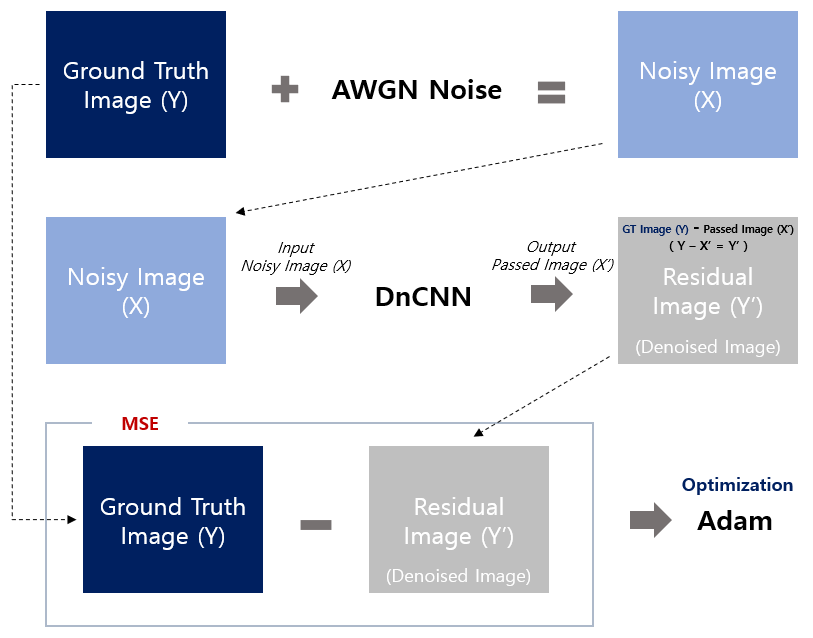

In [8]:
class DnCNN(nn.Module):
    def __init__(
        self,
        channels: int,
        num_of_layers: int,
        kernel_size: int,
        padding: int,
        features: int,
    ):
        super().__init__()

        layers = []
        layers.append(nn.Conv2d(in_channels=channels, out_channels=features, kernel_size=kernel_size, padding=padding, bias=False))
        layers.append(nn.SiLU(inplace=True))

        for _ in range(num_of_layers - 1):
            layers.append(nn.Conv2d(in_channels=features, out_channels=features, kernel_size=kernel_size, padding=padding, bias=False))
            layers.append(nn.GroupNorm(4, features))
            layers.append(nn.SiLU(inplace=True))

        layers.append(nn.Conv2d(in_channels=features, out_channels=channels, kernel_size=kernel_size, padding=padding, bias=False))

        self.dncnn = nn.Sequential(*layers)

    def forward(
        self,
        x: Tensor,
    ) -> Tensor:
        if len(x.shape) != 4:
            raise ValueError(f"Input tensor must be 4D, but got {len(x.shape)}D tensor.")

        out = x + self.dncnn(x)
        return out


# sanity check
_m = DnCNN(channels=1, num_of_layers=3, kernel_size=3, padding=1, features=8)
print("DnCNN out:", _m(torch.randn(1, 1, 64, 64)).shape)
del _m

DnCNN out: torch.Size([1, 1, 64, 64])


## 7. NoiseSimulator

**이미지마다 아래 4종 중 하나를 랜덤으로 골라 `NOISE_RANGES` 범위에서 sigma 를 뽑아** 적용한다.

- Gaussian noise

- Rician noise

- Uniform noise

- Salt and pepper noise

In [9]:
class NoisyType(str, Enum):
    Gaussian = "gaussian"
    Rician = "rician"
    Uniform = "uniform"
    SaltAndPepper = "salt_and_pepper"

    @classmethod
    def from_string(cls, value: str) -> "NoisyType":
        try:
            return cls(value)
        except ValueError as err:
            raise ValueError(f"Invalid NoisyType value: {value}. Must be one of {list(cls)} : {err}") from err


def gaussian_noise(img, sigma: float) -> torch.Tensor:
    noise = torch.randn_like(img) * sigma
    noisy_img = img + noise
    return noisy_img


def rician_noise(img, sigma: float) -> torch.Tensor:
    noise_real = torch.randn_like(img) * sigma
    noise_imag = torch.randn_like(img) * sigma
    noisy_img = torch.abs(img + noise_real + 1j * noise_imag)
    return noisy_img


def uniform_noise(img, sigma: float) -> torch.Tensor:
    noise = (torch.rand_like(img) * 2.0 - 1.0) * sigma
    return img + noise


def salt_and_pepper_noise(img, sigma: float) -> torch.Tensor:
    salt_prob = sigma / 2
    pepper_prob = sigma / 2
    noisy_img = img.clone()
    total_pixels = img.numel()

    # Salt noise
    num_salt = int(total_pixels * salt_prob)
    coords = [torch.randint(0, dim, (num_salt,)) for dim in img.shape]
    noisy_img[tuple(coords)] = img.max()
    # Pepper noise
    num_pepper = int(total_pixels * pepper_prob)
    coords = [torch.randint(0, dim, (num_pepper,)) for dim in img.shape]
    noisy_img[tuple(coords)] = 0  # Set to black

    return noisy_img


class NoiseSimulator:
    """단일 노이즈 타입 + 고정 sigma 를 이미지에 적용한다.

    `RandomNoiseSimulator` 가 (노이즈 종류, sigma) 를 뽑아서 이 클래스에 위임한다.

    구현 근거 (ref/dataset 로 역검증, claude/verify_noise.py 참고):
      - test_label(clean) / test_noise_only(noisy) / noise_meta.json(선언된 type·sigma)를
        비교하면 아래 4개 수식이 실제 데이터 생성기와 일치한다.
        gaussian / uniform / rician 은 오차 < 0.2%, salt&pepper 는 중복 좌표 샘플링까지 재현된다.
      - 생성기는 **clipping 을 하지 않는다.** (gaussian noisy 최소값 -0.298, 최대값 1.359)
        따라서 여기서도 clamp 를 하지 않는다. clamp 를 넣으면 train/test 분포가 어긋난다.
    """

    _DISPATCH: dict[str, Callable[[Tensor, float], Tensor]] = {
        NoisyType.Gaussian.value: gaussian_noise,
        NoisyType.Rician.value: rician_noise,
        NoisyType.Uniform.value: uniform_noise,
        NoisyType.SaltAndPepper.value: salt_and_pepper_noise,
    }

    def __init__(
        self,
        noisy_type: "NoisyType | str",
        sigma: float,
    ) -> None:
        self.noisy_type = noisy_type if isinstance(noisy_type, NoisyType) else NoisyType.from_string(str(noisy_type))
        sigma = float(sigma)
        if sigma < 0.0:
            raise ValueError(f"sigma must be non-negative, got {sigma}")
        self.sigma = sigma

    def __call__(
        self,
        img: Tensor,
    ) -> Tensor:
        if self.sigma == 0.0:
            # sigma=0 이면 노이즈가 없다. 원본을 그대로 쓰면 in-place 오염 위험이 있어 복사한다.
            return img.clone()
        noisy = self._DISPATCH[self.noisy_type.value](img, self.sigma)
        # rician 은 복소수 경유 결과라 dtype 이 바뀔 수 있어 입력 dtype 으로 맞춘다.
        return noisy.to(img.dtype)

    def __repr__(self) -> str:
        return f"NoiseSimulator(noisy_type={self.noisy_type.value}, sigma={self.sigma:.6f})"

class RandomNoiseSimulator:
    def __init__(
        self,
        noise_ranges: dict[str, tuple[float, float]] | None = None,
    ) -> None:
        self.noise_ranges = dict(noise_ranges) if noise_ranges is not None else dict(NOISE_RANGES)
        self.names = list(self.noise_ranges.keys())

    def _sample(self, rng) -> tuple[str, float]:
        name = rng.choice(self.names)
        low, high = self.noise_ranges[name]
        return name, rng.uniform(low, high)

    def __call__(
        self,
        img: torch.Tensor,
        seed: int | None = None,
    ) -> torch.Tensor:
        if seed is None:
            # 학습용: 매번 새로 뽑는다 (같은 이미지도 epoch 마다 다른 노이즈)
            name, sigma = self._sample(random)
            return NoiseSimulator(NoisyType.from_string(name), sigma)(img)

        # 검증/테스트용: 이미지마다 항상 같은 노이즈가 나오도록 seed 를 고정한다
        name, sigma = self._sample(random.Random(seed))
        torch_state = torch.random.get_rng_state()
        torch.manual_seed(seed)
        try:
            noisy = NoiseSimulator(NoisyType.from_string(name), sigma)(img)
        finally:
            torch.random.set_rng_state(torch_state)
        return noisy

    def describe(self, seed: int) -> tuple[str, float]:
        return self._sample(random.Random(seed))


## 7.5 [iter3] corrupted variant pool & blind-spot

### variant pool
`(clean 파일명, group, member)` 로부터 corrupted 이미지를 **결정론적으로** 만든다.

- group 별로 `(noise_type, sigma)` 를 한 번 정하고, member 0/1 은 **같은 조건의 서로 다른 실현**이다.
  (같은 촬영 조건에서 두 번 찍은 것에 해당 → N2N 의 전제)
- 따라서 clean 1장당 corrupted 는 `variant_groups × variant_per_group = 12` 장으로 고정된다.
- epoch 을 몇 번 돌려도 이 12장 밖의 corrupted 는 생성되지 않는다.

### blind-spot (N2V)
선택된 픽셀을 **이웃 픽셀 값으로 덮어써서** 네트워크가 그 위치의 원래 값을 볼 수 없게 만들고,
손실은 그 위치에서만 원래 noisy 값을 target 으로 계산한다. clean 은 쓰지 않는다.

경계에서는 clamp 대신 **오프셋을 반사(mirror)** 시킨다. clamp 를 쓰면 경계 픽셀에서
`이웃 == 자기 자신` 이 되어 blind-spot 성질이 깨지고 네트워크가 항등함수를 학습한다.


In [10]:
# ---------------- corrupted variant pool (규칙 준수용) ----------------

_VARIANT_SPEC_CACHE: dict[tuple[str, int], list[tuple[str, float]]] = {}


def variant_group_specs(
    name: str,
    n_group: int,
) -> list[tuple[str, float]]:
    """clean 파일 1장에 대해 group 별 (noise_type, sigma) 를 결정론적으로 확정한다.

    같은 group 의 member 들은 이 spec 을 공유하고 노이즈 실현(seed)만 다르다.
    """
    key = (name, n_group)
    cached = _VARIANT_SPEC_CACHE.get(key)
    if cached is not None:
        return cached

    rng = random.Random(zlib.crc32(f"variant:{name}".encode()))
    noise_names = list(NOISE_RANGES.keys())
    specs: list[tuple[str, float]] = []
    for _ in range(n_group):
        nz = rng.choice(noise_names)
        low, high = NOISE_RANGES[nz]
        specs.append((nz, rng.uniform(low, high)))

    _VARIANT_SPEC_CACHE[key] = specs
    return specs


def make_variant(
    label: Tensor,
    name: str,
    group: int,
    member: int,
    n_group: int,
) -> Tensor:
    """(clean, group, member) 에 대응하는 corrupted 이미지. 항상 같은 결과를 준다."""
    nz, sigma = variant_group_specs(name, n_group)[group]
    seed = zlib.crc32(f"{name}:{group}:{member}".encode())

    torch_state = torch.random.get_rng_state()
    torch.manual_seed(seed)
    try:
        noisy = NoiseSimulator(NoisyType.from_string(nz), sigma)(label)
    finally:
        torch.random.set_rng_state(torch_state)
    return noisy


# ---------------- N2V blind-spot ----------------


def n2v_blind_spot(
    noisy: Tensor,
    ratio: float,
    window: int,
) -> tuple[Tensor, Tensor]:
    """Noise2Void 의 blind-spot 입력과 손실 마스크를 만든다.

    Args:
        noisy: [B, C, H, W]
        ratio: 마스킹할 픽셀 비율
        window: 대체 픽셀을 뽑을 이웃 창 크기 (홀수)

    Returns:
        (마스킹된 입력, 손실 마스크). 마스크가 1인 위치에서만 손실을 계산한다.
    """
    b, c, h, w = noisy.shape
    n_mask = max(int(h * w * ratio), 1)
    total = b * n_mask
    dev = noisy.device

    # 인덱스는 CPU 에서 뽑아 재현성을 확보한 뒤 옮긴다 (CUDA generator 의존 제거)
    bi = torch.arange(b).repeat_interleave(n_mask)
    ys = torch.randint(0, h, (total,))
    xs = torch.randint(0, w, (total,))

    r = max(window // 2, 1)
    dy = torch.randint(-r, r + 1, (total,))
    dx = torch.randint(-r, r + 1, (total,))

    # (0, 0) 이면 자기 자신을 복사해 blind-spot 이 깨진다. 강제로 밀어낸다.
    both_zero = (dy == 0) & (dx == 0)
    dx = torch.where(both_zero, torch.ones_like(dx), dx)

    # 경계는 clamp 가 아니라 오프셋 반사. clamp 는 경계에서 이웃 == 자기 자신을 만든다.
    ny = ys + dy
    nx = xs + dx
    ny = torch.where((ny < 0) | (ny >= h), ys - dy, ny)
    nx = torch.where((nx < 0) | (nx >= w), xs - dx, nx)

    bi, ys, xs, ny, nx = (t.to(dev) for t in (bi, ys, xs, ny, nx))

    model_in = noisy.clone()
    mask = torch.zeros_like(noisy)
    for ci in range(c):
        model_in[bi, ci, ys, xs] = noisy[bi, ci, ny, nx]
        mask[bi, ci, ys, xs] = 1.0

    return model_in, mask


# ---------------- 자기검증 ----------------

_lab = torch.rand(1, 256, 256)
_specs = variant_group_specs("L1_dummy.npy", 6)
print("variant specs (group -> noise, sigma):")
for _g, (_nz, _sg) in enumerate(_specs):
    print(f"  group {_g}: {_nz:<16} sigma={_sg:.4f}")

_a = make_variant(_lab, "L1_dummy.npy", 0, 0, 6)
_b = make_variant(_lab, "L1_dummy.npy", 0, 1, 6)
_a2 = make_variant(_lab, "L1_dummy.npy", 0, 0, 6)
assert torch.equal(_a, _a2), "같은 (name, group, member) 는 항상 같아야 한다"
assert not torch.equal(_a, _b), "같은 group 의 member 0/1 은 서로 다른 실현이어야 한다"
print(f"\nmember 0/1 독립 실현 확인: mean|a-b| = {(_a - _b).abs().mean():.5f}")

_mi, _mk = n2v_blind_spot(_lab[None], ratio=0.05, window=5)
_changed = (_mi != _lab[None]).float().mean().item()
_hit = _mk.mean().item()
_same = ((_mk > 0) & (_mi == _lab[None])).sum().item()
print(f"n2v: mask 비율={_hit:.4f}  실제 변경된 픽셀 비율={_changed:.4f}  (마스크했지만 값이 같은 픽셀={_same})")
print("  ※ 값이 같은 픽셀은 이웃과 우연히 값이 일치한 경우로, blind-spot 위반이 아니다")


variant specs (group -> noise, sigma):
  group 0: gaussian         sigma=0.0598
  group 1: gaussian         sigma=0.0670
  group 2: rician           sigma=0.0908
  group 3: gaussian         sigma=0.0475
  group 4: uniform          sigma=0.1456
  group 5: gaussian         sigma=0.0789

member 0/1 독립 실현 확인: mean|a-b| = 0.06750
n2v: mask 비율=0.0485  실제 변경된 픽셀 비율=0.0485  (마스크했지만 값이 같은 픽셀=0)
  ※ 값이 같은 픽셀은 이웃과 우연히 값이 일치한 경우로, blind-spot 위반이 아니다


## 8. DataLoader

In [11]:
prob_flip: float = 0.5


class DataKey(IntEnum):
    Label = 0
    Noisy = 1
    Name = 2
    Target = 3  # [iter3] 학습 target. supervised=clean, n2n=짝 noisy, n2v=원본 noisy


@dataclass
class LoaderConfig:
    data_type: str
    batch: int
    num_workers: int
    shuffle: bool
    noisy_type: Literal["random"]
    noise_sigma: float
    noisy_path: str | None = None
    max_images: int | None = None
    # [iter3]
    train_mode: str = "supervised"
    variant_groups: int = 6
    variant_per_group: int = 2


class DataWrapper(Dataset):
    file_list: list[str]
    training_mode: bool
    noise_simulator: NoiseSimulator

    def __init__(
        self,
        file_path: list[str],
        data_type: str,
        training_mode: bool,
        noisy_type: str,
        noise_sigma: float,
        noisy_path: str | None = None,
        max_images: int | None = None,
        train_mode: str = "supervised",
        variant_groups: int = 6,
        variant_per_group: int = 2,
    ):
        self.training_mode = training_mode
        self.random_noise = str(noisy_type) == "random"
        if self.random_noise:
            self.noise_simulator = RandomNoiseSimulator()
        else:
            self.noise_simulator = NoiseSimulator(NoisyType.from_string(str(noisy_type)), noise_sigma)

        self.noisy_path = Path(noisy_path) if noisy_path is not None else None

        # [iter3]
        self.train_mode = train_mode
        self.variant_groups = variant_groups
        self.variant_per_group = variant_per_group

        super().__init__()
        total_list: list[str] = []
        for _file_path in file_path:
            total_list += glob.glob(f"{_file_path}/{data_type}")

        total_list = sorted(total_list)
        if max_images is not None:
            total_list = total_list[:max_images]

        self.file_list = total_list

    @staticmethod
    def _load_from_npy(
        file_npy: str,
    ) -> torch.Tensor:
        img = torch.from_numpy(np.load(file_npy)).type(torch.float)
        if len(img.shape) == 2:
            img = img.unsqueeze(0)
        return img

    def _augment(
        self,
        label: torch.Tensor,
        noisy: torch.Tensor | None = None,
    ):
        # label 과 noisy 에 동일한 flip 을 적용한다
        if random.random() > prob_flip:
            label = torch.flip(label, dims=[1])
            noisy = torch.flip(noisy, dims=[1]) if noisy is not None else None
        if random.random() > prob_flip:
            label = torch.flip(label, dims=[2])
            noisy = torch.flip(noisy, dims=[2]) if noisy is not None else None

        return label, noisy

    @staticmethod
    def _augment_many(
        tensors: list[torch.Tensor],
    ) -> list[torch.Tensor]:
        """[iter3] 여러 텐서에 동일한 flip 을 적용한다 (label/noisy/target 정렬 유지)."""
        if random.random() > prob_flip:
            tensors = [torch.flip(t, dims=[1]) for t in tensors]
        if random.random() > prob_flip:
            tensors = [torch.flip(t, dims=[2]) for t in tensors]
        return tensors

    def __getitem__(
        self,
        idx: int,
    ):
        path = self.file_list[idx]
        _name = os.path.basename(path)  # Windows(\) / POSIX(/) 모두 대응
        label = self._load_from_npy(path)

        # ---------- 1) 사전 생성된 noisy 파일 사용 (test) ----------
        if self.noisy_path is not None:
            noisy_file = self.noisy_path / _name
            if not noisy_file.exists():
                raise FileNotFoundError(f"Matching noisy file not found: {noisy_file}")
            noisy = self._load_from_npy(str(noisy_file))
            if self.training_mode:
                label, noisy = self._augment(label, noisy)
            return label, noisy, _name, label

        # ---------- 2) iter2 방식: 매 epoch 새 노이즈 (규칙 상한 초과) ----------
        if self.train_mode == "supervised":
            if self.training_mode:
                label, _ = self._augment(label)
                noisy = self.noise_simulator(label)
            elif self.random_noise:
                noisy = self.noise_simulator(label, seed=zlib.crc32(_name.encode()))
            else:
                noisy = self.noise_simulator(label)
            return label, noisy, _name, label

        # ---------- 3) iter3 방식: clean 당 12장 고정 풀에서만 샘플링 ----------
        n_group = self.variant_groups
        # 검증/테스트는 group 0 으로 고정해 epoch 간 재현성을 보장한다
        group = random.randrange(n_group) if self.training_mode else 0

        if self.train_mode == "n2n":
            # 입력/target 을 무작위로 바꿔 쓰면 pair 를 대칭적으로 활용한다
            if self.training_mode and random.random() < 0.5:
                m_in, m_tg = 1, 0
            else:
                m_in, m_tg = 0, 1
            noisy = make_variant(label, _name, group, m_in, n_group)
            target = make_variant(label, _name, group, m_tg, n_group)
            if self.training_mode:
                label, noisy, target = self._augment_many([label, noisy, target])
            return label, noisy, _name, target

        # supervised12 / n2v
        member = random.randrange(self.variant_per_group) if self.training_mode else 0
        noisy = make_variant(label, _name, group, member, n_group)
        if self.training_mode:
            label, noisy = self._augment_many([label, noisy])

        if self.train_mode == "supervised12":
            return label, noisy, _name, label
        if self.train_mode == "n2v":
            # target 은 마스킹 전 noisy. 마스킹은 학습 루프에서 GPU 로 수행한다.
            return label, noisy, _name, noisy.clone()

        raise KeyError(f"unknown train_mode: {self.train_mode}")

    def __len__(self) -> int:
        return len(self.file_list)


def get_data_wrapper_loader(
    file_path: list[str],
    training_mode: bool,
    loader_cfg: LoaderConfig,
) -> tuple[DataLoader, DataWrapper, int]:
    dataset = DataWrapper(
        file_path=file_path,
        data_type=loader_cfg.data_type,
        training_mode=training_mode,
        noisy_type=loader_cfg.noisy_type,
        noise_sigma=loader_cfg.noise_sigma,
        noisy_path=loader_cfg.noisy_path,
        max_images=loader_cfg.max_images,
        train_mode=loader_cfg.train_mode,
        variant_groups=loader_cfg.variant_groups,
        variant_per_group=loader_cfg.variant_per_group,
    )

    if len(dataset) == 0:
        raise FileNotFoundError(f"No data found in {file_path} with pattern {loader_cfg.data_type}")

    _ = dataset[0]

    dataloader = DataLoader(
        dataset,
        batch_size=loader_cfg.batch,
        num_workers=loader_cfg.num_workers,
        pin_memory=True,
        persistent_workers=loader_cfg.num_workers > 0,
        shuffle=loader_cfg.shuffle,
    )

    return (
        dataloader,
        dataset,
        len(dataset),
    )


### 데이터 확인

In [12]:
import matplotlib.pyplot as plt

_loader, _, _len = get_data_wrapper_loader(
    file_path=config.train_dataset,
    training_mode=True,
    loader_cfg=LoaderConfig(
        data_type=config.data_type,
        batch=4,
        num_workers=0,
        shuffle=True,
        noisy_type=config.noise_type,
        noise_sigma=config.noise_sigma,
        train_mode=config.train_mode,
        variant_groups=config.variant_groups,
        variant_per_group=config.variant_per_group,
    ),
)
print(f"train dataset length: {_len}")
print(f"train_mode : {config.train_mode}")
print(f"loss_model : {config.loss_model}")
if config.train_mode == "supervised":
    print(f"corrupted/clean: {config.train_epoch} (on-the-fly)")
else:
    print(f"corrupted/clean: {config.variant_groups * config.variant_per_group} (고정 풀)")
for k, v in NOISE_RANGES.items():
    print(f"  {k:16s} sigma {v[0]} ~ {v[1]}")

_label, _noisy, _name, _target = next(iter(_loader))
n = _label.shape[0]

# [iter3] train_mode 에 따라 실제로 네트워크가 보는 입력과 target 을 그린다
if config.train_mode == "n2v":
    _model_in, _mask = n2v_blind_spot(_noisy, config.n2v_mask_ratio, config.n2v_window)
    rows = [
        (_label, "clean (손실 미사용)"),
        (_noisy, "noisy"),
        (_model_in, "network 입력 (blind-spot)"),
        (_mask, "손실 마스크"),
    ]
elif config.train_mode == "n2n":
    rows = [
        (_label, "clean (손실 미사용)"),
        (_noisy, "network 입력 = noisy A"),
        (_target, "target = noisy B"),
        ((_noisy - _target).abs(), "|A - B| (독립 실현)"),
    ]
else:
    rows = [
        (_label, "clean"),
        (_noisy, "network 입력 = noisy"),
        (_target, "target = clean"),
        ((_noisy - _label).abs(), "|noisy - clean|"),
    ]

fig, axes = plt.subplots(len(rows), n, figsize=(3.1 * n, 3.1 * len(rows)))
for r, (tensor, row_title) in enumerate(rows):
    for i in range(n):
        arr = tensor[i, 0].numpy()
        is_diff = row_title.startswith("|") or "마스크" in row_title
        axes[r, i].imshow(arr, cmap="magma" if is_diff else "gray", vmin=None if is_diff else 0, vmax=None if is_diff else 1)
        axes[r, i].set_title(f"{row_title}\n{_name[i][:22]}" if r == 0 else row_title, fontsize=7)
        axes[r, i].axis("off")
fig.suptitle(f"train sample — train_mode={config.train_mode}")
fig.tight_layout()
plt.show()

# clean 이 손실에 안 쓰인다는 것을 수치로 확인
if config.train_mode in ("n2n", "n2v"):
    print(f"\n[label-free 확인] target 과 clean 의 차이: mean|target - clean| = {(_target - _label).abs().mean():.5f}")
    print("  0 이 아니면 target 이 clean 이 아니라는 뜻이다 (= label-free)")
else:
    print(f"\n[supervised 확인] mean|target - clean| = {(_target - _label).abs().mean():.5f} (0 이어야 한다)")


Output hidden; open in https://colab.research.google.com to view.

## 9. train / test core functions

In [13]:
NETWORK = DnCNN | torch.nn.DataParallel
OPTIM = Adam | AdamW


class ModelType(str, Enum):
    DnCNN = "dncnn"

    @classmethod
    def from_string(cls, value: str) -> "ModelType":
        try:
            return cls(value)
        except ValueError as err:
            raise ValueError(f"Invalid ModelType value: {value}. Must be one of {list(cls)} : {err}") from err


def get_network(
    device: torch.device | None,
    model_type: str,
    dncnnconfig: DnCNNConfig,
) -> NETWORK:
    if device is None:
        raise TypeError("device is not to be None")

    if ModelType.from_string(model_type) == ModelType.DnCNN:
        return DnCNN(
            channels=dncnnconfig.channels,
            num_of_layers=dncnnconfig.num_of_layers,
            kernel_size=dncnnconfig.kernel_size,
            padding=dncnnconfig.padding,
            features=dncnnconfig.features,
        )
    else:
        raise KeyError("model type not matched")


def get_optim(
    network: NETWORK | None,
    optimizer: str,
) -> OPTIM | None:
    if network is None:
        return None
    if optimizer == "adam":
        return Adam(network.parameters(), betas=(0.9, 0.99))
    elif optimizer == "adamw":
        return AdamW(network.parameters(), betas=(0.9, 0.99), weight_decay=0.0)
    else:
        raise KeyError("optimizer not matched")


def get_loss_func(
    loss_model: str,
) -> Callable:
    if loss_model == "l1":
        return torch.nn.L1Loss(reduction="none")
    elif loss_model == "l2":
        return torch.nn.MSELoss(reduction="none")
    else:
        raise KeyError("loss func not matched")


def get_learning_rate(
    epoch: int,
    lr: float,
    lr_decay: float,
    lr_tol: int,
    schedule: str = "exp",
    total_epoch: int = 1,
    lr_min_ratio: float = 0.0,
) -> float:
    """epoch 별 learning rate.

    [iter2-B] "cosine" 을 추가했다.
      - epoch < lr_tol 구간은 초기 lr 유지 (warmup 대신 plateau)
      - 이후 total_epoch 마지막까지 lr -> lr*lr_min_ratio 로 코사인 감쇠

    iter1 이 쓴 "exp" 는 lr_decay**(epoch-lr_tol) 로, 총 epoch 수와 무관하게 감쇠한다.
    그래서 10 epoch 에서 이미 초기값의 36% 까지 떨어졌고 아직 성능이 오르는 중에 LR 을 줄였다.
    cosine 은 total_epoch 에 맞춰 감쇠 속도가 정해지므로 이 문제가 없다.
    """
    if schedule == "cosine":
        if epoch < lr_tol:
            return lr
        span = max(total_epoch - lr_tol - 1, 1)
        t = min(max(epoch - lr_tol, 0), span) / span
        lr_min = lr * lr_min_ratio
        return lr_min + 0.5 * (lr - lr_min) * (1.0 + math.cos(math.pi * t))

    if schedule != "exp":
        raise KeyError(f"unknown lr_schedule: {schedule}")

    factor = epoch - lr_tol if lr_tol < epoch else 0
    return lr * (lr_decay**factor)


def set_optimizer_lr(
    optimizer: OPTIM | None,
    learning_rate: float,
) -> OPTIM | None:
    if optimizer is None:
        return None
    for param_group in optimizer.param_groups:
        param_group["lr"] = learning_rate
    return optimizer


def log_summary(
    init_time: float,
    state: MetricController,
    log_std: bool = False,
) -> None:
    spend_time = seconds_to_dhms(time.time() - init_time)
    for key in state.state_dict:
        if log_std:
            summary = f"{spend_time} | {key}: {state.mean(key):0.3e} + {state.std(key):0.3e} "
            logger.info(summary)
        else:
            summary = f"{spend_time} | {key}: {state.mean(key):0.3e}"
            logger.info(summary)


def save_checkpoint(
    network: NETWORK,
    run_dir: Path,
    epoch: str | int | None = None,
) -> None:
    if epoch is None:
        epoch = "best"
    os.makedirs(run_dir / "checkpoints", exist_ok=True)
    torch.save(
        {
            "model_state_dict": network.state_dict(),
            "model_config": asdict(dncnnconfig),
        },
        run_dir / f"checkpoints/checkpoint_{epoch}.ckpt",
    )


def zero_optimizers(
    optim_list: list[OPTIM | None],
) -> None:
    for opt in optim_list:
        if opt is not None:
            opt.zero_grad()


def step_optimizers(
    optim_list: list[OPTIM | None],
) -> None:
    for opt in optim_list:
        if opt is not None:
            opt.step()


def save_result_to_mat(
    test_dir: Path,
    batch_cnt: int,
    tesner_dict: dict[str, Tensor | None],
    img_cnt: int,
) -> None:
    os.makedirs(test_dir, exist_ok=True)
    save_dict = {}

    if batch_cnt == 0:
        logger.warning("batch_cnt is 0, no data to save")
        return

    for i in range(batch_cnt):
        for key, value in tesner_dict.items():
            if value is not None:
                save_dict[key] = value.cpu().detach().numpy()[i, ...]

        idx = img_cnt + i + 1
        savemat(f"{test_dir}/{idx}_res.mat", save_dict)


def compute_train_loss(
    network: NETWORK,
    noisy: Tensor,
    target: Tensor,
) -> Tensor:
    """[iter3] train_mode 에 따른 손실. 이미지별 스칼라 [B,1,1,1] 을 돌려준다.

      supervised / supervised12 : target = clean label            (지도)
      n2n                       : target = 같은 clean 의 다른 noisy (label-free)
      n2v                       : 입력 일부를 이웃값으로 덮고, 그 위치에서만
                                  원본 noisy 를 target 으로 사용     (label-free)

    n2n / n2v 경로는 clean label 을 손실에 전혀 사용하지 않는다.
    """
    loss_func = get_loss_func(config.loss_model)

    if config.train_mode == "n2v":
        model_in, mask = n2v_blind_spot(
            noisy,
            ratio=config.n2v_mask_ratio,
            window=config.n2v_window,
        )
    else:
        model_in, mask = noisy, None

    output = network.forward(model_in) if network.training else network(model_in)
    per_pixel = loss_func(output, target)

    if mask is None:
        return torch.mean(per_pixel, dim=(1, 2, 3), keepdim=True)

    num = torch.sum(per_pixel * mask, dim=(1, 2, 3), keepdim=True)
    den = torch.sum(mask, dim=(1, 2, 3), keepdim=True).clamp(min=1.0)
    return num / den


def train_epoch_dncnn(
    _data,
    network: NETWORK,
    epoch: int,
    train_state: MetricController,
) -> int:
    noisy: Tensor = _data[DataKey.Noisy].to(config.device)
    target: Tensor = _data[DataKey.Target].to(config.device)

    img_cnt_minibatch = noisy.shape[0]

    loss = compute_train_loss(network=network, noisy=noisy, target=target)

    torch.mean(loss).backward()
    train_state.add("loss", loss)

    return img_cnt_minibatch


def valid_selfsup_loss(
    data_loader: DataLoader,
    network: NETWORK,
) -> float:
    """[iter3] clean label 을 쓰지 않는 검증 손실. 완전 label-free 모델 선택용.

    supervised 계열에서는 target 이 clean 이므로 의미가 없어 nan 을 돌려준다.
    """
    if config.train_mode not in ("n2n", "n2v"):
        return float("nan")

    network.eval()
    model = network.module if isinstance(network, torch.nn.DataParallel) else network

    # 마스킹 난수를 고정해 epoch 간 비교 가능하게 한다
    torch_state = torch.random.get_rng_state()
    torch.manual_seed(20260901)

    total, count = 0.0, 0
    try:
        with torch.no_grad():
            for _data in data_loader:
                noisy = _data[DataKey.Noisy].to(config.device)
                target = _data[DataKey.Target].to(config.device)
                loss = compute_train_loss(network=model, noisy=noisy, target=target)
                total += float(loss.sum())
                count += loss.numel()
    finally:
        torch.random.set_rng_state(torch_state)

    return total / max(count, 1)


def train_epoch(
    train_loader: DataLoader,
    train_len: int,
    network: NETWORK,
    optim_list: list[OPTIM | None],
    epoch: int,
) -> float:
    train_state = MetricController()
    train_state.reset()
    network.train()

    logging_cnt: int = 1
    img_cnt: int = 0
    batch_pbar = tqdm(
        train_loader,
        desc=f"  train ep {epoch + 1}",
        unit="batch",
        leave=False,
    )
    for _data in batch_pbar:
        zero_optimizers(optim_list=optim_list)
        if ModelType.from_string(config.model_type) == ModelType.DnCNN:
            img_cnt_minibatch = train_epoch_dncnn(
                _data=_data,
                network=network,
                epoch=epoch,
                train_state=train_state,
            )
        else:
            raise KeyError("model type not matched")

        step_optimizers(optim_list=optim_list)
        img_cnt += img_cnt_minibatch
        batch_pbar.set_postfix(loss=f"{train_state.mean('loss'):0.3e}")
        if img_cnt > (train_len / config.logging_density * logging_cnt):
            log_summary(init_time=config.init_time, state=train_state)
            logging_cnt += 1

    log_summary(init_time=config.init_time, state=train_state)
    return float(train_state.mean("loss"))


def test_part_dncnn(
    _data,
    test_dir: Path,
    model: NETWORK,
    save_val: bool,
    test_state: MetricController,
    img_cnt: int,
) -> int:
    noisy = _data[DataKey.Noisy].to(config.device)
    label = _data[DataKey.Label].to(config.device)

    batch_cnt = noisy.shape[0]

    validate_tensors([noisy, label])
    validate_tensor_dimensions([noisy, label], 4)

    output = model(noisy)

    validate_tensors([output])
    validate_tensor_dimensions([output], 4)

    for idx in range(output.shape[0]):
        test_state.add("psnr", calculate_psnr(output[idx : idx + 1, ...], label[idx : idx + 1, ...]))
        test_state.add("ssim", calculate_ssim(output[idx : idx + 1, ...], label[idx : idx + 1, ...]))

    if save_val:
        save_result_to_mat(
            test_dir=test_dir,
            batch_cnt=batch_cnt,
            tesner_dict={
                "noisy": noisy,
                "output": output,
                "label": label,
            },
            img_cnt=img_cnt,
        )

    return batch_cnt


def test_part(
    epoch: int,
    data_loader: DataLoader,
    network: NETWORK,
    run_dir: Path,
    save_val: bool,
    desc: str = "valid",
) -> float:
    test_state = MetricController()
    test_state.reset()
    network.eval()
    model = network.module if isinstance(network, torch.nn.DataParallel) else network

    img_cnt: int = 0
    batch_pbar = tqdm(data_loader, desc=f"  {desc}", unit="batch", leave=False)
    for _data in batch_pbar:
        if ModelType.from_string(config.model_type) == ModelType.DnCNN:
            batch_cnt = test_part_dncnn(
                _data=_data,
                test_dir=run_dir / f"test/ep_{epoch}",
                model=model,
                save_val=save_val and img_cnt <= config.save_max_idx,
                test_state=test_state,
                img_cnt=img_cnt,
            )
        else:
            raise KeyError("model type not matched")

        img_cnt += batch_cnt
        batch_pbar.set_postfix(psnr=f"{test_state.mean('psnr'):0.2f}")

    log_summary(init_time=config.init_time, state=test_state, log_std=True)

    # numpy.float32 그대로 반환하면 json 직렬화에서 터진다. float 로 고정한다.
    primary_metric = float(test_state.mean("psnr"))
    return primary_metric

## 10. Validation 결과 시각화


저장 위치: `{run_dir}/valid_png/ep_{epoch}/{파일명}.png`

In [14]:
import matplotlib.pyplot as plt

VALID_FIG_MAX: int = 4  # validation 마다 저장할 이미지 수


def save_comparison_figures(
    epoch: int,
    data_loader: DataLoader,
    network: NETWORK,
    run_dir: Path,
    max_images: int = VALID_FIG_MAX,
    tag: str = "valid",
    subdir: str | None = None,
    noise_lookup: dict[str, str] | None = None,
    title_prefix: str | None = None,
) -> Path:
    save_dir = run_dir / (subdir if subdir is not None else f"{tag}_png/ep_{epoch:03d}")
    os.makedirs(save_dir, exist_ok=True)

    network.eval()
    model = network.module if isinstance(network, torch.nn.DataParallel) else network
    dataset = data_loader.dataset

    saved = 0
    with torch.no_grad():
        for _data in data_loader:
            label = _data[DataKey.Label].to(config.device)
            noisy = _data[DataKey.Noisy].to(config.device)
            names = _data[DataKey.Name]

            output = model(noisy)

            for i in range(output.shape[0]):
                if saved >= max_images:
                    break

                lab_i, noi_i, out_i = label[i : i + 1], noisy[i : i + 1], output[i : i + 1]
                psnr_in = calculate_psnr(noi_i, lab_i).item()
                ssim_in = calculate_ssim(noi_i, lab_i).item()
                psnr_out = calculate_psnr(out_i, lab_i).item()
                ssim_out = calculate_ssim(out_i, lab_i).item()

                lab = lab_i.cpu().numpy().squeeze()
                noi = noi_i.cpu().numpy().squeeze()
                out = out_i.cpu().numpy().squeeze()
                err = np.abs(out - lab)

                vmax = float(np.percentile(lab, 98) * 1.2)
                err_vmax = float(max(err.max(), 1e-6))

                fig, axes = plt.subplots(1, 4, figsize=(16, 4.6))
                panels = [
                    (lab, "Original (label)", "gray", 0.0, vmax),
                    (noi, f"Noisy\nPSNR {psnr_in:.2f} dB / SSIM {ssim_in:.4f}", "gray", 0.0, vmax),
                    (out, f"Denoised\nPSNR {psnr_out:.2f} dB / SSIM {ssim_out:.4f}", "gray", 0.0, vmax),
                    (err, f"Error |denoised - label|\nmax {err_vmax:.3f}", "magma", 0.0, err_vmax),
                ]
                for ax, (img, title, cmap, lo, hi) in zip(axes, panels):
                    im = ax.imshow(img, cmap=cmap, vmin=lo, vmax=hi)
                    ax.set_title(title, fontsize=10)
                    ax.axis("off")
                fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.02)

                noise_desc = ""
                if getattr(dataset, "random_noise", False) and dataset.noisy_path is None:
                    _nz, _sg = dataset.noise_simulator.describe(zlib.crc32(names[i].encode()))
                    noise_desc = f" | noise={_nz} sigma={_sg:.4f}"
                elif noise_lookup:
                    noise_desc = f" | noise={noise_lookup.get(names[i], 'unknown')}"

                fig.suptitle(
                    f"{title_prefix if title_prefix is not None else f'epoch {epoch}'}"
                    f" | {names[i]}{noise_desc}"
                    f" | PSNR {psnr_in:.2f} -> {psnr_out:.2f} dB",
                    fontsize=11,
                )
                fig.tight_layout(rect=(0, 0, 1, 0.90))
                fig.savefig(save_dir / f"{names[i].replace('.npy', '')}.png", dpi=150, bbox_inches="tight")
                plt.close(fig)
                saved += 1

            if saved >= max_images:
                break

    logger.info(f"Saved {saved} comparison figures to {save_dir}")
    return save_dir

## 11. Train

In [15]:
class Trainer:
    run_dir: Path
    network: NETWORK
    train_loader: DataLoader
    train_len: int
    valid_loader: DataLoader
    optims: list[OPTIM | None]

    def __init__(
        self,
    ) -> None:
        config.init_time = time.time()
        config.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(config.device)

        # dir setting
        self.run_dir = config.run_dir / f"{call_next_id(config.run_dir):05d}_train"
        logger_add_handler(logger, f"{self.run_dir/'log.log'}", config.log_lv)
        logger.info(separator())
        logger.info(f"Run dir: {self.run_dir}")
        os.makedirs(self.run_dir, exist_ok=True)

        # log config
        logger.info(separator())
        logger.info("General Config")
        config_dict = asdict(config)
        for k in config_dict:
            logger.info(f"{k}:{config_dict[k]}")
        logger.info(separator())
        logger.info("Model Config")
        config_dict = asdict(dncnnconfig)
        for k in config_dict:
            logger.info(f"{k}:{config_dict[k]}")

    def __call__(
        self,
    ) -> None:
        self._set_data()
        self._set_network()
        self._train()

    @error_wrap
    def _set_data(
        self,
    ) -> None:
        logger.info(separator())
        # [iter3] train_mode / variant 예산을 로더로 전달
        _iter3 = dict(
            train_mode=config.train_mode,
            variant_groups=config.variant_groups,
            variant_per_group=config.variant_per_group,
        )
        train_loader_cfg = LoaderConfig(
            data_type=config.data_type,
            batch=config.train_batch,
            num_workers=config.num_workers,
            shuffle=True,
            noisy_type=config.noise_type,
            noise_sigma=config.noise_sigma,
            max_images=config.max_train_images,
            **_iter3,
        )

        valid_loader_cfg = LoaderConfig(
            # [iter2-C] test 분포(L1_)에 맞춘 validation
            data_type=config.valid_data_type or config.data_type,
            batch=config.valid_batch,
            num_workers=config.num_workers,
            shuffle=False,
            noisy_type=config.noise_type,
            noise_sigma=config.noise_sigma,
            max_images=config.max_valid_images,
            **_iter3,
        )

        self.train_loader, _, self.train_len = get_data_wrapper_loader(
            file_path=config.train_dataset,
            training_mode=True,
            loader_cfg=train_loader_cfg,
        )
        logger.info(f"Train dataset length : {self.train_len}")

        self.valid_loader, _, valid_len = get_data_wrapper_loader(
            file_path=config.valid_dataset,
            training_mode=False,
            loader_cfg=valid_loader_cfg,
        )
        logger.info(f"Valid dataset length : {valid_len} (pattern: {valid_loader_cfg.data_type})")

    @error_wrap
    def _set_network(
        self,
    ) -> None:
        self.network = get_network(
            device=config.device,
            model_type=config.model_type,
            dncnnconfig=dncnnconfig,
        )

        self.optims = [
            get_optim(
                network=self.network,
                optimizer=config.optimizer,
            ),
        ]

        if config.parallel:
            self.network = torch.nn.DataParallel(self.network).to(config.device)
        else:
            self.network = self.network.to(config.device)

    @error_wrap
    def _train(
        self,
    ) -> None:
        logger.info(separator())
        logger.info(f"Train start | train_mode={config.train_mode} loss={config.loss_model} select_by={config.select_by}")

        # [iter3] select_by 에 따라 부호를 맞춘 score 로 통일 (클수록 좋음)
        best_score: float = -float("inf")
        primary_metric: float = 0.0
        self.history: list[dict] = []
        postfix: dict[str, str] = {}
        epoch_pbar = tqdm(
            range(config.train_epoch),
            desc="Epoch",
            unit="epoch",
            leave=True,
        )

        for epoch in epoch_pbar:
            lr_epoch = get_learning_rate(
                epoch=epoch,
                lr=config.lr,
                lr_decay=config.lr_decay,
                lr_tol=config.lr_tol,
                schedule=config.lr_schedule,
                total_epoch=config.train_epoch,
                lr_min_ratio=config.lr_min_ratio,
            )
            postfix["lr"] = f"{lr_epoch:0.3e}"
            epoch_pbar.set_postfix(postfix)
            tqdm.write(f"Epoch {epoch + 1}/{config.train_epoch} | lr={lr_epoch:0.3e}")

            optims = [set_optimizer_lr(optimizer=optim, learning_rate=lr_epoch) for optim in self.optims]

            train_loss = train_epoch(
                train_loader=self.train_loader,
                train_len=self.train_len,
                network=self.network,
                optim_list=optims,
                epoch=epoch,
            )
            postfix["loss"] = f"{train_loss:0.3e}"
            epoch_pbar.set_postfix(postfix)

            # [iter2-D] 매 epoch 저장하면 60 x 2.4MB 가 Drive 에 쌓인다. best 는 아래에서 별도 저장.
            is_last = epoch == config.train_epoch - 1
            if config.ckpt_interval <= 1 or is_last or (epoch + 1) % config.ckpt_interval == 0:
                save_checkpoint(
                    network=self.network,
                    run_dir=self.run_dir,
                    epoch=epoch,
                )

            if epoch < config.valid_tol:
                continue

            if epoch % config.valid_interval == 0:
                primary_metric, val_self = self._valid(epoch)
                postfix["val_psnr"] = f"{primary_metric:0.2f}"
                if not math.isnan(val_self):
                    postfix["val_self"] = f"{val_self:0.3e}"
                epoch_pbar.set_postfix(postfix)

                # MetricController.mean() 은 numpy.float32 를 돌려주므로 반드시 float 로 캐스팅한다.
                # (캐스팅 없이 json.dump 하면 TypeError 가 나고, _train 이 @error_wrap 으로
                #  감싸여 있어 예외가 로그로만 남은 채 학습이 조용히 중단된다)
                self.history.append(
                    {
                        "epoch": int(epoch + 1),
                        "lr": float(lr_epoch),
                        "train_loss": float(train_loss),
                        "val_psnr": float(primary_metric),
                        "val_selfsup": None if math.isnan(val_self) else float(val_self),
                    }
                )
                try:
                    with open(self.run_dir / "history.json", "w") as f:
                        json.dump(self.history, f, indent=2)
                except Exception as err:
                    # 기록 실패가 학습을 죽이지 않게 한다
                    logger.warning(f"Failed to write history.json: {err}")

                # [iter3] selfsup 은 작을수록 좋으므로 부호를 뒤집어 score 로 통일
                if config.select_by == "selfsup" and not math.isnan(val_self):
                    score = -float(val_self)
                else:
                    score = float(primary_metric)

                if score > best_score:
                    best_score = score
                    logger.success(
                        f"Best model renew (by {config.select_by}: score {score:0.6f} | "
                        f"valid psnr {primary_metric:0.4f})"
                    )
                    save_checkpoint(
                        network=self.network,
                        run_dir=self.run_dir,
                    )

    @error_wrap
    def _valid(
        self,
        epoch: int,
    ) -> tuple[float, float]:
        """(validation PSNR, self-supervised validation loss) 를 돌려준다.

        [iter3] self-supervised loss 는 clean 을 쓰지 않으므로,
        select_by="psnr" 로 돌려도 history.json 에 함께 기록해 두면
        "완전 label-free 로 골랐다면 어느 epoch 이었는지" 를 사후 확인할 수 있다.
        """
        logger.info("Valid")
        with torch.no_grad():
            primary_metric = test_part(
                epoch=epoch,
                data_loader=self.valid_loader,
                network=self.network,
                run_dir=self.run_dir,
                save_val=False,
                desc=f"valid ep {epoch + 1}",
            )

        val_self = valid_selfsup_loss(data_loader=self.valid_loader, network=self.network)
        if not math.isnan(val_self):
            logger.info(f"valid selfsup loss ({config.loss_model}): {val_self:0.6e}")

        # [iter2-D] 비교 이미지는 fig_interval 주기 + 마지막 epoch 에만 남긴다.
        # (매 epoch 저장하면 60 epoch x 4장 = 240장, 약 360MB 가 Drive 에 쌓인다)
        is_last = epoch == config.train_epoch - 1
        if config.fig_interval <= 1 or is_last or (epoch + 1) % config.fig_interval == 0:
            try:
                save_comparison_figures(
                    epoch=epoch,
                    data_loader=self.valid_loader,
                    network=self.network,
                    run_dir=self.run_dir,
                )
            except Exception as err:
                logger.warning(f"Failed to save validation figures: {err}")

        return primary_metric, val_self

### 학습 실행

In [16]:
trainer = Trainer()
trainer()

TRAIN_RUN_DIR = trainer.run_dir
print("train run dir:", TRAIN_RUN_DIR)

cuda
2026-09-01 00:55:33 [INFO] ####################################################################################################
2026-09-01 00:55:33 [INFO] Run dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00002_train
2026-09-01 00:55:33 [INFO] ####################################################################################################
2026-09-01 00:55:33 [INFO] General Config
2026-09-01 00:55:33 [INFO] train_dataset:['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/train']
2026-09-01 00:55:33 [INFO] valid_dataset:['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/val']
2026-09-01 00:55:33 [INFO] test_dataset:['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_label']
2026-09-01 00:55:33 [INFO] data_type:*.npy
2026-09-01 00:55:33 [INFO] valid_data_type:L1_*.npy
2026-09-01 00:55:33 [INFO] test_noisy_dir:/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_noise_only

Epoch:   0%|          | 0/60 [00:00<?, ?epoch/s]

Epoch 1/60 | lr=1.000e-04


  train ep 1:   0%|          | 0/455 [00:00<?, ?batch/s]

2026-09-01 00:59:09 [INFO] 00h 03m 35s | loss: 7.815e-02
2026-09-01 00:59:41 [INFO] 00h 04m 07s | loss: 7.415e-02
2026-09-01 01:00:09 [INFO] 00h 04m 35s | loss: 7.095e-02
2026-09-01 01:00:39 [INFO] 00h 05m 06s | loss: 6.878e-02
2026-09-01 01:00:39 [INFO] Valid


...

2026-09-01 02:11:44 [INFO] 01h 16m 10s | psnr: 3.567e+01 + 9.236e+00 
2026-09-01 02:11:44 [INFO] 01h 16m 10s | ssim: 9.354e-01 + 8.817e-02 
2026-09-01 02:11:44 [INFO] valid selfsup loss (l1): 4.165852e-02
Epoch 60/60 | lr=2.000e-06


  train ep 60:   0%|          | 0/455 [00:00<?, ?batch/s]

2026-09-01 02:12:03 [INFO] 01h 16m 29s | loss: 4.982e-02
2026-09-01 02:12:21 [INFO] 01h 16m 47s | loss: 5.021e-02
2026-09-01 02:12:38 [INFO] 01h 17m 04s | loss: 5.033e-02
2026-09-01 02:12:56 [INFO] 01h 17m 22s | loss: 5.023e-02
2026-09-01 02:12:56 [INFO] Valid


  valid ep 60:   0%|          | 0/43 [00:00<?, ?batch/s]

2026-09-01 02:12:57 [INFO] 01h 17m 23s | psnr: 3.567e+01 + 9.292e+00 
2026-09-01 02:12:57 [INFO] 01h 17m 23s | ssim: 9.358e-01 + 8.716e-02 
2026-09-01 02:12:58 [INFO] valid selfsup loss (l1): 4.167906e-02
2026-09-01 02:13:01 [INFO] Saved 4 comparison figures to /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00002_train/valid_png/ep_059
train run dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00002_train


## 학습 결과

best checkpoint 는 **validation PSNR** 이 가장 높았던 시점의 가중치이고,
`{run_dir}/checkpoints/checkpoint_best.ckpt` 에 저장된다.


In [17]:
best_ckpt = TRAIN_RUN_DIR / "checkpoints/checkpoint_best.ckpt"
print("best checkpoint:", best_ckpt, "| exists:", best_ckpt.exists())

valid_pngs = sorted((TRAIN_RUN_DIR / "valid_png").rglob("*.png"))
print(f"validation figures: {len(valid_pngs)} png in {TRAIN_RUN_DIR / 'valid_png'}")
for p in valid_pngs[-4:]:
    print(" ", p)


best checkpoint: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00002_train/checkpoints/checkpoint_best.ckpt | exists: True
validation figures: 24 png in /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00002_train/valid_png
  /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00002_train/valid_png/ep_059/L1_04e524d382fc4f1aecdf6bbf39bd5b0f.png
  /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00002_train/valid_png/ep_059/L1_0aceacb0b3bbb83e38dd3f314b5b61b8.png
  /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00002_train/valid_png/ep_059/L1_0b01fddd63d7c84949f7439279d7bd21.png
  /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00002_train/valid_png/ep_059/L1_0b8e81c4fb1673f558be432fc1e3360f.png


## 12. 학습이 끝난 뒤 테스트 (best checkpoint)

학습 중에는 validation 만 돌고, test 는 여기서 **best checkpoint 로 한 번만** 돌린다.
(best 는 validation PSNR 기준으로 고른 가중치다.)


결과물: `{run_dir}/test_metrics.json` (영상별 지표), `{run_dir}/test_png/*.png` (비교 이미지)

In [18]:
TEST_MAX_FIG: int = 8  # 저장할 비교 이미지 수

TEST_RUN_DIR = globals().get("TRAIN_RUN_DIR")
if TEST_RUN_DIR is None:
    raise RuntimeError("학습 셀을 먼저 실행하거나 TEST_RUN_DIR 을 직접 지정할 것 (예: RUN_DIR / '00000_train')")

BEST_CKPT = TEST_RUN_DIR / "checkpoints/checkpoint_best.ckpt"

if config.device is None:
    config.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if config.init_time == 0.0:
    config.init_time = time.time()


def load_checkpoint_network(
    ckpt_path: Path,
    device: torch.device,
) -> DnCNN:
    checkpoint_data = torch.load(ckpt_path, map_location="cpu", weights_only=True)

    if not (("model_state_dict" in checkpoint_data) and ("model_config" in checkpoint_data)):
        raise KeyError(f"Invalid checkpoint: {ckpt_path}")

    modelconfig = DnCNNConfig(**checkpoint_data["model_config"])
    network = DnCNN(
        channels=modelconfig.channels,
        num_of_layers=modelconfig.num_of_layers,
        kernel_size=modelconfig.kernel_size,
        padding=modelconfig.padding,
        features=modelconfig.features,
    )

    _state_dict = {k.replace("module.", ""): v for k, v in checkpoint_data["model_state_dict"].items()}
    network.load_state_dict(_state_dict, strict=True)

    logger.info(f"Loaded checkpoint: {ckpt_path}")
    for k, v in asdict(modelconfig).items():
        logger.info(f"{k}:{v}")

    return network.to(device).eval()


test_network = load_checkpoint_network(BEST_CKPT, config.device)

test_loader, _, test_len = get_data_wrapper_loader(
    file_path=config.test_dataset,
    training_mode=False,
    loader_cfg=LoaderConfig(
        data_type=config.data_type,
        batch=config.valid_batch,
        num_workers=config.num_workers,
        shuffle=False,
        noisy_type=config.noise_type,
        noise_sigma=config.noise_sigma,
        noisy_path=config.test_noisy_dir,
        train_mode=config.train_mode,
        variant_groups=config.variant_groups,
        variant_per_group=config.variant_per_group,
    ),
)
print(f"checkpoint : {BEST_CKPT}")
print(f"label      : {config.test_dataset[0]}")
print(f"noisy      : {config.test_noisy_dir or f'on-the-fly ({config.noise_type})'}")
print(f"test images: {test_len}")

2026-09-01 02:13:01 [INFO] Loaded checkpoint: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00002_train/checkpoints/checkpoint_best.ckpt
2026-09-01 02:13:01 [INFO] channels:1
2026-09-01 02:13:01 [INFO] num_of_layers:17
2026-09-01 02:13:01 [INFO] kernel_size:3
2026-09-01 02:13:01 [INFO] padding:1
2026-09-01 02:13:01 [INFO] features:64
checkpoint : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00002_train/checkpoints/checkpoint_best.ckpt
label      : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_label
noisy      : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_noise_only/test_noise_only
test images: 100


In [19]:
noise_lookup: dict[str, str] = {}
if config.test_noisy_dir is not None:
    _meta = Path(config.test_noisy_dir) / "noise_meta.json"
    if _meta.exists():
        with open(_meta) as f:
            noise_lookup = {r["file"]: r["noise_type"] for r in json.load(f)}
        print(f"noise_meta.json: {len(noise_lookup)} entries")

test_state = MetricController()
test_state.reset()
rows: list[dict] = []

with torch.no_grad():
    for _data in tqdm(test_loader, desc="test", unit="batch"):
        label = _data[DataKey.Label].to(config.device)
        noisy = _data[DataKey.Noisy].to(config.device)
        names = _data[DataKey.Name]

        output = test_network(noisy)

        for i in range(output.shape[0]):
            out_i, lab_i, noi_i = output[i : i + 1], label[i : i + 1], noisy[i : i + 1]
            psnr_out = calculate_psnr(out_i, lab_i)
            ssim_out = calculate_ssim(out_i, lab_i)
            test_state.add("psnr", psnr_out)
            test_state.add("ssim", ssim_out)
            rows.append(
                {
                    "file": names[i],
                    "noise_type": noise_lookup.get(names[i], "unknown"),
                    "psnr": psnr_out.item(),
                    "ssim": ssim_out.item(),
                    "psnr_in": calculate_psnr(noi_i, lab_i).item(),
                    "ssim_in": calculate_ssim(noi_i, lab_i).item(),
                }
            )

log_summary(init_time=config.init_time, state=test_state, log_std=True)

with open(TEST_RUN_DIR / "test_metrics.json", "w") as f:
    json.dump(rows, f, indent=2)

print()
print(f"{'noise':<18}{'n':>5}{'PSNR in':>10}{'PSNR out':>10}{'SSIM in':>10}{'SSIM out':>10}")
print("-" * 63)
for nz in [*NOISE_RANGES.keys(), "unknown"]:
    sub = [r for r in rows if r["noise_type"] == nz]
    if not sub:
        continue
    print(
        f"{nz:<18}{len(sub):>5}"
        f"{np.mean([r['psnr_in'] for r in sub]):>10.3f}"
        f"{np.mean([r['psnr'] for r in sub]):>10.3f}"
        f"{np.mean([r['ssim_in'] for r in sub]):>10.4f}"
        f"{np.mean([r['ssim'] for r in sub]):>10.4f}"
    )
print("-" * 63)
print(
    f"{'ALL':<18}{len(rows):>5}"
    f"{np.mean([r['psnr_in'] for r in rows]):>10.3f}"
    f"{np.mean([r['psnr'] for r in rows]):>10.3f}"
    f"{np.mean([r['ssim_in'] for r in rows]):>10.4f}"
    f"{np.mean([r['ssim'] for r in rows]):>10.4f}"
)

test_png_dir = save_comparison_figures(
    epoch=0,
    data_loader=test_loader,
    network=test_network,
    run_dir=TEST_RUN_DIR,
    max_images=TEST_MAX_FIG,
    subdir="test_png",
    noise_lookup=noise_lookup,
    title_prefix="test (best ckpt)",
)
print(f"\nmetrics : {TEST_RUN_DIR / 'test_metrics.json'}")
print(f"figures : {test_png_dir}")

noise_meta.json: 100 entries


test:   0%|          | 0/100 [00:00<?, ?batch/s]

2026-09-01 02:13:35 [INFO] 01h 18m 01s | psnr: 3.336e+01 + 6.126e+00 
2026-09-01 02:13:35 [INFO] 01h 18m 01s | ssim: 9.421e-01 + 7.146e-02 

noise                 n   PSNR in  PSNR out   SSIM in  SSIM out
---------------------------------------------------------------
gaussian             25    27.668    34.554    0.6835    0.9374
rician               25    24.079    29.883    0.7104    0.8957
uniform              25    29.631    34.849    0.7950    0.9489
salt_and_pepper      25    17.304    34.145    0.4746    0.9866
---------------------------------------------------------------
ALL                 100    24.671    33.358    0.6659    0.9421
2026-09-01 02:13:43 [INFO] Saved 8 comparison figures to /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00002_train/test_png

metrics : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00002_train/test_metrics.json
figures : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denois

### 저장된 test 결과 이미지

In [20]:
from IPython.display import Image, display

for p in sorted(test_png_dir.glob("*.png"))[:3]:
    print(p.name)
    display(Image(filename=str(p)))

Output hidden; open in https://colab.research.google.com to view.

## 13. 베이스라인 비교 (mean filter / median filter)

conventional filter와 학습한 DnCNN 비교

| 방법 | 원본 | 설명 |
|---|---|---|
| DnCNN | `model/dncnn.py` | 학습된 best checkpoint |
| mean filter | `filter/mean_filter.py` | 3x3 이웃 평균 |
| median filter | `filter/median_filter.py` | 3x3 이웃 중앙값 (salt & pepper 에 강함) |

세 방법 모두 **같은 test 데이터(`test_noise_only`)** 에 대해 PSNR / SSIM 을 잰다.


In [21]:
def _as_bchw(img: Tensor) -> tuple[Tensor, int]:
    """[H,W] / [C,H,W] / [B,C,H,W] 를 모두 [B,C,H,W] 로 맞춘다."""
    dim = img.dim()
    if dim == 2:
        return img[None, None], dim
    if dim == 3:
        return img[None], dim
    if dim == 4:
        return img, dim
    raise ValueError(f"unsupported image dim: {dim}")


def _restore_dim(img: Tensor, dim: int) -> Tensor:
    if dim == 2:
        return img[0, 0]
    if dim == 3:
        return img[0]
    return img


def mean_filter(
    img: Tensor,
    kernel_size: int = 3,
) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    x = functional.pad(x, (pad, pad, pad, pad), mode="reflect")
    out = functional.avg_pool2d(x, kernel_size=kernel_size, stride=1)
    return _restore_dim(out, dim)


def median_filter(
    img: Tensor,
    kernel_size: int = 3,
) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    x = functional.pad(x, (pad, pad, pad, pad), mode="reflect")
    # [B, C, H, W, k, k] -> 마지막 k*k 축에서 중앙값
    patches = x.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    out = patches.reshape(*patches.shape[:4], -1).median(dim=-1).values
    return _restore_dim(out, dim)


def adaptive_filter(
    img: Tensor,
    kernel_size: int = 5,
    noise_var: Tensor | float | None = None,
) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    xp = functional.pad(x, (pad, pad, pad, pad), mode="reflect")

    local_mean = functional.avg_pool2d(xp, kernel_size=kernel_size, stride=1)
    local_sq = functional.avg_pool2d(xp.pow(2), kernel_size=kernel_size, stride=1)
    local_var = (local_sq - local_mean.pow(2)).clamp_min(0.0)

    if noise_var is None:
        noise_var = local_var.flatten(2).median(dim=-1).values[:, :, None, None]

    ratio = (noise_var / local_var.clamp_min(1e-8)).clamp(max=1.0)
    out = x - ratio * (x - local_mean)
    return _restore_dim(out, dim)

In [22]:
BASELINE_KERNEL: int = 3
ADAPTIVE_KERNEL: int = 5

METHODS: list[str] = ["noisy", "dncnn", "mean", "median", "adaptive"]
METHOD_LABEL: dict[str, str] = {
    "noisy": "Noisy (input)",
    "dncnn": "DnCNN (best)",
    "mean": f"Mean {BASELINE_KERNEL}x{BASELINE_KERNEL}",
    "median": f"Median {BASELINE_KERNEL}x{BASELINE_KERNEL}",
    "adaptive": f"Adaptive {ADAPTIVE_KERNEL}x{ADAPTIVE_KERNEL}",
}

baseline_rows: list[dict] = []
noise_samples: dict[str, dict] = {}

test_network.eval()
with torch.no_grad():
    for _data in tqdm(test_loader, desc="baseline", unit="batch"):
        label = _data[DataKey.Label].to(config.device)
        noisy = _data[DataKey.Noisy].to(config.device)
        names = _data[DataKey.Name]

        outputs = {
            "noisy": noisy,
            "dncnn": test_network(noisy),
            "mean": mean_filter(noisy, kernel_size=BASELINE_KERNEL),
            "median": median_filter(noisy, kernel_size=BASELINE_KERNEL),
            "adaptive": adaptive_filter(noisy, kernel_size=ADAPTIVE_KERNEL),
        }

        for i in range(label.shape[0]):
            lab_i = label[i : i + 1]
            row = {"file": names[i], "noise_type": noise_lookup.get(names[i], "unknown")}
            for key in METHODS:
                pred_i = outputs[key][i : i + 1]
                row[f"psnr_{key}"] = calculate_psnr(pred_i, lab_i).item()
                row[f"ssim_{key}"] = calculate_ssim(pred_i, lab_i).item()
            baseline_rows.append(row)

            if row["noise_type"] not in noise_samples:
                sample = {"name": names[i], "metrics": row, "label": lab_i.cpu().numpy().squeeze()}
                for key in METHODS:
                    sample[key] = outputs[key][i : i + 1].cpu().numpy().squeeze()
                noise_samples[row["noise_type"]] = sample


def print_baseline_table(metric: str, width: int = 15) -> None:
    fmt = ".3f" if metric == "psnr" else ".4f"
    print(f"[{metric.upper()}]")
    print(f"{'noise':<18}{'n':>5}" + "".join(f"{METHOD_LABEL[m]:>{width}}" for m in METHODS))
    print("-" * (23 + width * len(METHODS)))
    for nz in [*NOISE_RANGES.keys(), "unknown"]:
        sub = [r for r in baseline_rows if r["noise_type"] == nz]
        if not sub:
            continue
        cells = "".join(f"{np.mean([r[f'{metric}_{m}'] for r in sub]):>{width}{fmt}}" for m in METHODS)
        print(f"{nz:<18}{len(sub):>5}{cells}")
    print("-" * (23 + width * len(METHODS)))
    cells = "".join(f"{np.mean([r[f'{metric}_{m}'] for r in baseline_rows]):>{width}{fmt}}" for m in METHODS)
    print(f"{'ALL':<18}{len(baseline_rows):>5}{cells}")


print()
print_baseline_table("psnr")
print()
print_baseline_table("ssim")

with open(TEST_RUN_DIR / "baseline_metrics.json", "w") as f:
    json.dump(baseline_rows, f, indent=2)
print(f"\nmetrics : {TEST_RUN_DIR / 'baseline_metrics.json'}")

baseline:   0%|          | 0/100 [00:00<?, ?batch/s]


[PSNR]
noise                 n  Noisy (input)   DnCNN (best)       Mean 3x3     Median 3x3   Adaptive 5x5
--------------------------------------------------------------------------------------------------
gaussian             25         27.668         34.554         26.316         27.382         30.078
rician               25         24.079         29.883         23.669         24.080         27.046
uniform              25         29.631         34.849         26.263         26.779         30.521
salt_and_pepper      25         17.304         34.145         23.196         28.496         21.164
--------------------------------------------------------------------------------------------------
ALL                 100         24.671         33.358         24.861         26.684         27.202

[SSIM]
noise                 n  Noisy (input)   DnCNN (best)       Mean 3x3     Median 3x3   Adaptive 5x5
---------------------------------------------------------------------------------------------

### 노이즈 종류별 결과 비교 (4 x 8)

In [23]:
ERROR_CMAP = "magma"
GRID_COLS = ["dncnn", "mean", "median", "adaptive"]

row_order = [nz for nz in [*NOISE_RANGES.keys(), "unknown"] if nz in noise_samples]
if not row_order:
    raise RuntimeError("noise_samples 가 비어 있다. 앞의 baseline 셀을 먼저 실행할 것")

fig, axes = plt.subplots(len(row_order), 2 * len(GRID_COLS), figsize=(25, 4.2 * len(row_order)))
axes = np.asarray(axes).reshape(len(row_order), 2 * len(GRID_COLS))

for r, nz in enumerate(row_order):
    sample = noise_samples[nz]
    lab = sample["label"]
    metrics = sample["metrics"]

    vmax = float(np.percentile(lab, 98) * 1.2)
    errors = {key: np.abs(sample[key] - lab) for key in GRID_COLS}
    err_vmax = float(max(np.percentile(np.stack(list(errors.values())), 99.5), 1e-6))

    for c, key in enumerate(GRID_COLS):
        ax = axes[r, 2 * c]
        ax.imshow(sample[key], cmap="gray", vmin=0.0, vmax=vmax)
        ax.set_title(
            f"{METHOD_LABEL[key]}\nPSNR {metrics[f'psnr_{key}']:.2f} dB / SSIM {metrics[f'ssim_{key}']:.4f}",
            fontsize=9,
        )
        if c == 0:
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_ylabel(f"{nz}\nnoisy {metrics['psnr_noisy']:.2f} dB", fontsize=10)
        else:
            ax.axis("off")

        ax_err = axes[r, 2 * c + 1]
        im = ax_err.imshow(errors[key], cmap=ERROR_CMAP, vmin=0.0, vmax=err_vmax)
        ax_err.set_title(f"|error|  max {errors[key].max():.3f}", fontsize=9)
        ax_err.axis("off")

    fig.colorbar(im, ax=axes[r, -1], fraction=0.046, pad=0.02)

fig.suptitle(
    f"DnCNN vs mean/median filter  |  test set: {Path(config.test_dataset[0]).name}"
    f"  |  error scale shared per row",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.subplots_adjust(hspace=0.22)

grid_path = TEST_RUN_DIR / "baseline_grid.png"
fig.savefig(grid_path, dpi=150, bbox_inches="tight")
print(f"saved: {grid_path}")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 14. [iter3] iteration 비교

iter1 / iter2 는 이전 run 의 실측값을 상수로 넣어두었다.
iter3 은 이 노트북에서 방금 계산한 `rows` 를 사용한다.

`history.json` 에서 **self-supervised 기준으로 골랐을 때의 epoch** 도 함께 확인한다.
이것이 "clean 을 전혀 쓰지 않는 완전 label-free 파이프라인" 의 근거가 된다.



[PSNR]
run                              gaussian           rician          uniform  salt_and_pepper              ALL
-------------------------------------------------------------------------------------------------------------
iter1 (sup, 10ep)                  32.282           28.727           32.060           29.298           30.592
iter2 (sup, 60ep)                  34.343           30.607           34.421           37.979           34.337
adaptive 5x5                       30.078           27.046           30.521           21.164           27.202
median 3x3                         27.382           24.080           26.779           28.496           26.684
iter3 (n2n, l1)                    34.554           29.883           34.849           34.145           33.358

[SSIM]
run                              gaussian           rician          uniform  salt_and_pepper              ALL
--------------------------------------------------------------------------------------------------------

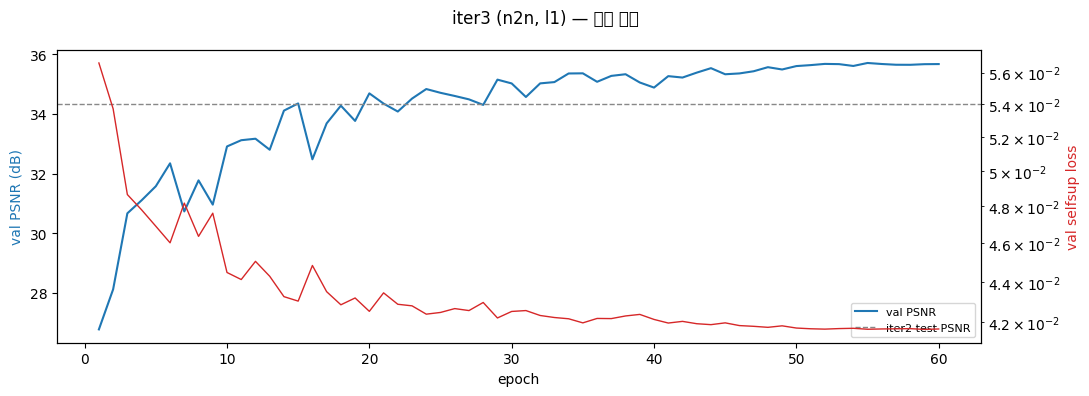

In [24]:
# ---------------- iteration 비교 ----------------

PREV_RUNS: dict[str, dict[str, tuple[float, float]]] = {
    "iter1 (sup, 10ep)": {
        "gaussian": (32.282, 0.8963),
        "rician": (28.727, 0.8632),
        "uniform": (32.060, 0.9279),
        "salt_and_pepper": (29.298, 0.8915),
        "ALL": (30.592, 0.8947),
    },
    "iter2 (sup, 60ep)": {
        "gaussian": (34.343, 0.9327),
        "rician": (30.607, 0.9042),
        "uniform": (34.421, 0.9496),
        "salt_and_pepper": (37.979, 0.9842),
        "ALL": (34.337, 0.9427),
    },
    "adaptive 5x5": {
        "gaussian": (30.078, 0.8544),
        "rician": (27.046, 0.8294),
        "uniform": (30.521, 0.8867),
        "salt_and_pepper": (21.164, 0.5971),
        "ALL": (27.202, 0.7919),
    },
    "median 3x3": {
        "gaussian": (27.382, 0.7667),
        "rician": (24.080, 0.7596),
        "uniform": (26.779, 0.8212),
        "salt_and_pepper": (28.496, 0.8831),
        "ALL": (26.684, 0.8076),
    },
}

_this = {}
for _nz in [*NOISE_RANGES.keys()]:
    _sub = [r for r in rows if r["noise_type"] == _nz]
    if _sub:
        _this[_nz] = (float(np.mean([r["psnr"] for r in _sub])), float(np.mean([r["ssim"] for r in _sub])))
_this["ALL"] = (float(np.mean([r["psnr"] for r in rows])), float(np.mean([r["ssim"] for r in rows])))

_this_name = f"iter3 ({config.train_mode}, {config.loss_model})"
ALL_RUNS = {**PREV_RUNS, _this_name: _this}
_order = ["gaussian", "rician", "uniform", "salt_and_pepper", "ALL"]

for _metric, _idx, _fmt in (("PSNR", 0, "9.3f"), ("SSIM", 1, "9.4f")):
    print(f"\n[{_metric}]")
    header = f"{'run':<24}" + "".join(f"{k:>17}" for k in _order)
    print(header)
    print("-" * len(header))
    for _run, _vals in ALL_RUNS.items():
        line = f"{_run:<24}"
        for k in _order:
            line += f"{_vals[k][_idx]:>17.{4 if _idx else 3}f}" if k in _vals else f"{'-':>17}"
        print(line)

# iter2 대비 격차
print(f"\n[{_this_name} - iter2 (supervised 60ep)]  PSNR 격차")
for k in _order:
    if k in _this:
        d = _this[k][0] - PREV_RUNS["iter2 (sup, 60ep)"][k][0]
        print(f"  {k:<18} {d:+8.3f} dB")

# ---------------- label-free 모델 선택 검증 ----------------
_hist_path = TEST_RUN_DIR / "history.json"
if _hist_path.exists():
    with open(_hist_path) as f:
        _hist = json.load(f)
    _by_psnr = max(_hist, key=lambda r: r["val_psnr"])
    print(f"\n[모델 선택 비교]")
    print(f"  val PSNR   기준 best : epoch {_by_psnr['epoch']:>3}  (val psnr {_by_psnr['val_psnr']:.4f})")
    _with_self = [r for r in _hist if r.get("val_selfsup") is not None]
    if _with_self:
        _by_self = min(_with_self, key=lambda r: r["val_selfsup"])
        print(
            f"  selfsup    기준 best : epoch {_by_self['epoch']:>3}  "
            f"(selfsup {_by_self['val_selfsup']:.6e}, 그 epoch 의 val psnr {_by_self['val_psnr']:.4f})"
        )
        _gap = _by_psnr["val_psnr"] - _by_self["val_psnr"]
        print(f"  → clean 을 전혀 쓰지 않고 골랐을 때의 손실: {_gap:+.4f} dB")
        if abs(_gap) < 0.15:
            print("     격차가 작으므로 '완전 label-free 파이프라인' 으로 보고해도 무리가 없다")
    else:
        print("  selfsup 기록 없음 (supervised 모드)")

    # 학습 곡선
    import matplotlib.pyplot as plt

    _eps = [r["epoch"] for r in _hist]
    fig, ax1 = plt.subplots(figsize=(11, 4))
    ax1.plot(_eps, [r["val_psnr"] for r in _hist], color="#1f77b4", label="val PSNR")
    ax1.axhline(PREV_RUNS["iter2 (sup, 60ep)"]["ALL"][0], color="#888", ls="--", lw=1, label="iter2 test PSNR")
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("val PSNR (dB)", color="#1f77b4")
    ax1.legend(loc="lower right", fontsize=8)
    if _with_self:
        ax2 = ax1.twinx()
        ax2.plot(_eps, [r["val_selfsup"] for r in _hist], color="#d62728", lw=1, label="val selfsup loss")
        ax2.set_ylabel("val selfsup loss", color="#d62728")
        ax2.set_yscale("log")
    fig.suptitle(f"{_this_name} — 학습 곡선")
    fig.tight_layout()
    plt.show()
